In [1]:
# IMPORT LIBRARY

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [2]:
# LOAD DATASET
df = pd.read_csv('audi.csv')

df.head(10)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0
5,A1,2016,13900,Automatic,32260,Petrol,30,58.9,1.4
6,A6,2016,13250,Automatic,76788,Diesel,30,61.4,2.0
7,A4,2016,11750,Manual,75185,Diesel,20,70.6,2.0
8,A3,2015,10200,Manual,46112,Petrol,20,60.1,1.4
9,A1,2016,12000,Manual,22451,Petrol,30,55.4,1.4


In [3]:
# DATA UNDERSTANDING

print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 10668 entries, 0 to 10667
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10668 non-null  str    
 1   year          10668 non-null  int64  
 2   price         10668 non-null  int64  
 3   transmission  10668 non-null  str    
 4   mileage       10668 non-null  int64  
 5   fuelType      10668 non-null  str    
 6   tax           10668 non-null  int64  
 7   mpg           10668 non-null  float64
 8   engineSize    10668 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 750.2 KB
None
               year          price        mileage           tax           mpg  \
count  10668.000000   10668.000000   10668.000000  10668.000000  10668.000000   
mean    2017.100675   22896.685039   24827.244001    126.011436     50.770022   
std        2.167494   11714.841888   23505.257205     67.170294     12.949782   
min     1997.000000    1490.000000       

In [4]:
# CEK MISSING VALUES

df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [5]:
# DATA PREPROCESSING

# Menghapus missing value
df = df.dropna()

# Feature Engineering (menambah umur mobil)
df['car_age'] = 2026 - df['year']

# Drop kolom tidak penting
df = df.drop(['model', 'year'], axis=1)

# Encoding data kategorikal
le = LabelEncoder()
df['transmission'] = le.fit_transform(df['transmission'])
df['fuelType'] = le.fit_transform(df['fuelType'])

df.head()

,price,transmission,mileage,fuelType,tax,mpg,engineSize,car_age
0,12500,1,15735,2,150,55.4,1.4,9
1,16500,0,36203,0,20,64.2,2.0,10
2,11000,1,29946,2,30,55.4,1.4,10
3,16800,0,25952,0,145,67.3,2.0,9
4,17300,1,1998,2,145,49.6,1.0,7


In [6]:
# CEK JUMLAH DATA DAN FITUR

print("Shape data:", df.shape)
print("Kolom:")
print(df.columns)

Shape data: (10668, 8)
Kolom:
Index(['price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize', 'car_age'],
      dtype='str')


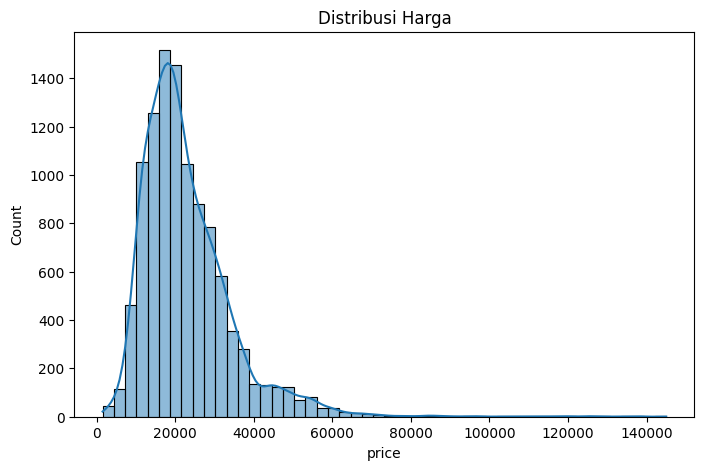

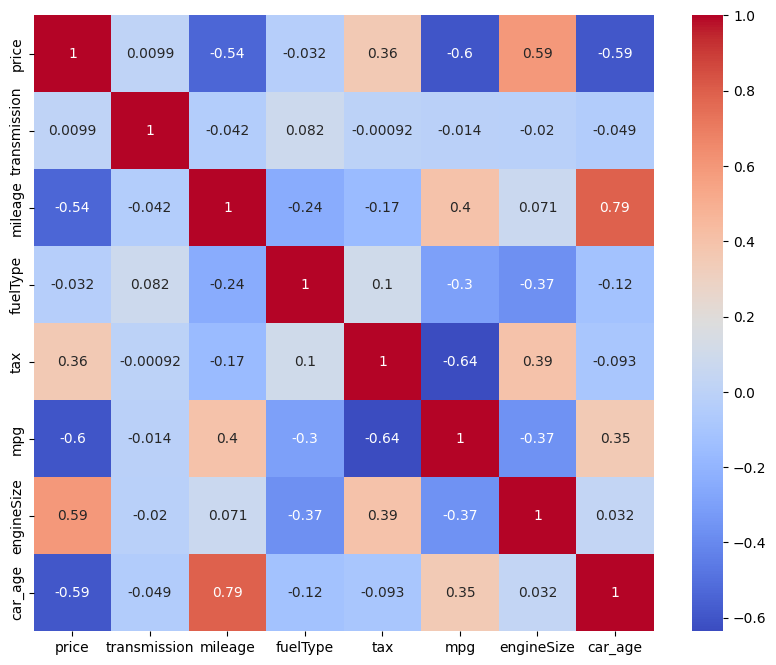

In [7]:
# EXPLORATORY DATA ANALYSIS (EDA)

# Distribusi harga
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribusi Harga')
plt.show()

# Korelasi antar fitur
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [8]:
# HANDLING OUTLIER

# Buang outlier ekstrem 
df = df[(df['price'] < df['price'].quantile(0.99))]
df = df[(df['price'] > df['price'].quantile(0.01))]

In [9]:
# SPLIT FEATURE & TARGET

X = df.drop('price', axis=1)
y = df['price']

# Transform target (biar model lebih akurat)
y = np.log1p(y)

In [12]:
# SCALING DATA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
# DATA SPLIT 70:30

X_train70, X_test30, y_train70, y_test30 = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

In [14]:
# DATA SPLIT 80:20

X_train80, X_test20, y_train80, y_test20 = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [15]:
# DATA SPLIT 90:10

X_train90, X_test10, y_train90, y_test10 = train_test_split(
    X_scaled, y, test_size=0.1, random_state=42
)

In [16]:
# FUNGSI EVALUASI MODEL 

def evaluate_regression(model, X_train, X_test, y_train, y_test):
    
    # Training model
    model.fit(X_train, y_train)
    
    # Prediksi data training
    y_pred_train = model.predict(X_train)
    
    # Prediksi data testing
    y_pred_test = model.predict(X_test)
    
    print("===================================")
    print("MODEL :", model.__class__.__name__)
    print("===================================")
    
    print("\nHASIL TRAINING")
    print("MAE  :", mean_absolute_error(y_train, y_pred_train))
    print("RMSE :", np.sqrt(mean_squared_error(y_train, y_pred_train)))
    print("R2   :", r2_score(y_train, y_pred_train))
    
    print("\nHASIL TESTING")
    print("MAE  :", mean_absolute_error(y_test, y_pred_test))
    print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_test)))
    print("R2   :", r2_score(y_test, y_pred_test))

In [17]:
# TUNING RIDGE

ridge = GridSearchCV(
    Ridge(),
    {'alpha': [0.1, 1, 10]},
    cv=3
)

ridge.fit(X_train80, y_train80)

y_pred_ridge = ridge.predict(X_test20)

print(ridge.best_params_)

{'alpha': 10}


In [18]:
# TUNING RANDOM FOREST

rf = GridSearchCV(
    RandomForestRegressor(),
    {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None]
    },
    cv=3
)

rf.fit(X_train80, y_train80)

y_pred_rf = rf.predict(X_test20)

print(rf.best_params_)

{'max_depth': 20, 'n_estimators': 200}


In [19]:
# TUNING XGBOOST

xgb = GridSearchCV(
    XGBRegressor(),
    {
        'n_estimators': [200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.05, 0.1]
    },
    cv=3
)

xgb.fit(X_train80, y_train80)

y_pred_xgb = xgb.predict(X_test20)

print(xgb.best_params_)

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}


In [20]:
# EVALUASI MODEL

hasil = pd.DataFrame({
    "Model": ["Ridge", "Random Forest", "XGBoost"],
    "MAE": [
        mean_absolute_error(y_test20, y_pred_ridge),
        mean_absolute_error(y_test20, y_pred_rf),
        mean_absolute_error(y_test20, y_pred_xgb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test20, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test20, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test20, y_pred_xgb))
    ],
    "R2 Score": [
        r2_score(y_test20, y_pred_ridge),
        r2_score(y_test20, y_pred_rf),
        r2_score(y_test20, y_pred_xgb)
    ]
})

print(hasil.round(3))

           Model    MAE   RMSE  R2 Score
0          Ridge  0.119  0.164     0.861
1  Random Forest  0.082  0.117     0.929
2        XGBoost  0.079  0.106     0.942


In [21]:
# EVALUASI TRAINING vs TESTING SEMUA SPLIT

def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

# ========================
# SPLIT 70:30
# ========================
print("=== SPLIT 70:30 ===")

# RIDGE
ridge_70 = GridSearchCV(Ridge(), {'alpha': [0.1, 1, 10]}, cv=3)
ridge_70.fit(X_train70, y_train70)

print("\nRIDGE")
print("Training:", evaluate(y_train70, ridge_70.predict(X_train70)))
print("Testing :", evaluate(y_test30, ridge_70.predict(X_test30)))

# RF
rf_70 = GridSearchCV(RandomForestRegressor(), {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None]
}, cv=3)
rf_70.fit(X_train70, y_train70)

print("\nRANDOM FOREST")
print("Training:", evaluate(y_train70, rf_70.predict(X_train70)))
print("Testing :", evaluate(y_test30, rf_70.predict(X_test30)))

# XGB
xgb_70 = GridSearchCV(XGBRegressor(), {
    'n_estimators': [200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1]
}, cv=3)
xgb_70.fit(X_train70, y_train70)

print("\nXGBOOST")
print("Training:", evaluate(y_train70, xgb_70.predict(X_train70)))
print("Testing :", evaluate(y_test30, xgb_70.predict(X_test30)))


# ========================
# SPLIT 80:20
# ========================
print("\n\n=== SPLIT 80:20 ===")

ridge_80 = GridSearchCV(Ridge(), {'alpha': [0.1, 1, 10]}, cv=3)
ridge_80.fit(X_train80, y_train80)

print("\nRIDGE")
print("Training:", evaluate(y_train80, ridge_80.predict(X_train80)))
print("Testing :", evaluate(y_test20, ridge_80.predict(X_test20)))

rf_80 = GridSearchCV(RandomForestRegressor(), {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None]
}, cv=3)
rf_80.fit(X_train80, y_train80)

print("\nRANDOM FOREST")
print("Training:", evaluate(y_train80, rf_80.predict(X_train80)))
print("Testing :", evaluate(y_test20, rf_80.predict(X_test20)))

xgb_80 = GridSearchCV(XGBRegressor(), {
    'n_estimators': [200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1]
}, cv=3)
xgb_80.fit(X_train80, y_train80)

print("\nXGBOOST")
print("Training:", evaluate(y_train80, xgb_80.predict(X_train80)))
print("Testing :", evaluate(y_test20, xgb_80.predict(X_test20)))


# ========================
# SPLIT 90:10
# ========================
print("\n\n=== SPLIT 90:10 ===")

ridge_90 = GridSearchCV(Ridge(), {'alpha': [0.1, 1, 10]}, cv=3)
ridge_90.fit(X_train90, y_train90)

print("\nRIDGE")
print("Training:", evaluate(y_train90, ridge_90.predict(X_train90)))
print("Testing :", evaluate(y_test10, ridge_90.predict(X_test10)))

rf_90 = GridSearchCV(RandomForestRegressor(), {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None]
}, cv=3)
rf_90.fit(X_train90, y_train90)

print("\nRANDOM FOREST")
print("Training:", evaluate(y_train90, rf_90.predict(X_train90)))
print("Testing :", evaluate(y_test10, rf_90.predict(X_test10)))

xgb_90 = GridSearchCV(XGBRegressor(), {
    'n_estimators': [200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1]
}, cv=3)
xgb_90.fit(X_train90, y_train90)

print("\nXGBOOST")
print("Training:", evaluate(y_train90, xgb_90.predict(X_train90)))
print("Testing :", evaluate(y_test10, xgb_90.predict(X_test10)))

=== SPLIT 70:30 ===

RIDGE
Training: {'MAE': 0.11672860589228261, 'RMSE': np.float64(0.1574387216770688), 'R2': 0.8623817563944378}
Testing : {'MAE': 0.11828184888215897, 'RMSE': np.float64(0.16067998445404733), 'R2': 0.8632133788736893}

RANDOM FOREST
Training: {'MAE': 0.031462587678664077, 'RMSE': np.float64(0.04320499880810824), 'R2': 0.9896361553128805}
Testing : {'MAE': 0.08092762120228324, 'RMSE': np.float64(0.11279757231562099), 'R2': 0.9325907391539101}

XGBOOST
Training: {'MAE': 0.06103061074474687, 'RMSE': np.float64(0.08109034330931811), 'R2': 0.963491736266155}
Testing : {'MAE': 0.07802881592402217, 'RMSE': np.float64(0.10422050836570894), 'R2': 0.9424525036272929}


=== SPLIT 80:20 ===

RIDGE
Training: {'MAE': 0.11657211735200715, 'RMSE': np.float64(0.15705404532992454), 'R2': 0.8631523013125514}
Testing : {'MAE': 0.11857798393223098, 'RMSE': np.float64(0.16381994034855193), 'R2': 0.8606404489740309}

RANDOM FOREST
Training: {'MAE': 0.031277429297414325, 'RMSE': np.float64

In [22]:
# INFERENCE (UJI COBA MANUAL)

data_baru = pd.DataFrame([{
    'mileage': 30000,
    'tax': 150,
    'mpg': 50,
    'engineSize': 1.5,
    'transmission': 1,
    'fuelType': 1,
    'car_age': 2026 - 2018
}])

data_baru = data_baru[X.columns]

data_baru_scaled = scaler.transform(data_baru)

pred_log = xgb.best_estimator_.predict(data_baru_scaled)
pred = np.expm1(pred_log)

print("Prediksi harga mobil:", pred[0])

Prediksi harga mobil: 19016.123
